# Polarization and Isofrequency Surface Calculations for MoOCl₂

**Associated manuscript:** *Spatiotemporal Visualization of Long-Range Anisotropic Plasmon Polaritons in Hyperbolic MoOCl₂*

This notebook computes the bulk electromagnetic mode structure of the biaxial van der Waals material MoOCl₂. It reproduces:
- **Figure S2** (Supplementary Information): Polarization maps of the *a* and *b* modes as a function of wavevector.
- **Figures 2B–C, 2E–F** (Main text): Isofrequency contours (IFCs) showing Re(*k*_z) and Im(*k*_z) for both extraordinary modes.

## Physical background

MoOCl₂ is a biaxial material described by a diagonal dielectric tensor ε = diag(ε_x, ε_y, ε_z). The wave equation in such a medium yields a quartic in *k*_z (the Booker quartic), whose two roots correspond to two extraordinary modes — the *a* mode (polarized predominantly along the crystal *a* axis) and the *b* mode (along *b*). These modes transition between propagating, evanescent, and ghost character depending on the in-plane wavevector (*k*_x, *k*_y), as determined by the zeros and sign of the Booker quartic discriminant (see Supplementary Information §2 for derivations).

## Table of Contents
1. [Imports and Constants](#1-imports-and-constants)
2. [Dielectric Models and Data](#2-dielectric-models-and-data)
3. [Booker Quartic: k_z Solver](#3-booker-quartic-kz-solver)
4. [Polarization Vector Calculations](#4-polarization-vector-calculations)
5. [Isofrequency Surface Calculations](#5-isofrequency-surface-calculations)
6. [Generate Publication Figures](#6-generate-publication-figures)


## 1. Imports and Constants <a id="1-imports-and-constants"></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm, colors
import pandas as pd
from pathlib import Path
import os

# Speed of light in units consistent with energy in eV and wavevector in μm⁻¹
# c = ħc = 0.197 eV·μm  (i.e. E = ħck → k = E/0.197 for k in μm⁻¹)
C_LIGHT = 0.197  # eV·μm

# Default evaluation energy (770 nm = 1.610 eV), used throughout for IFC plots
ENERGY_DEFAULT = 1240.0 / 770.0  # eV

# Path to literature dielectric data (relative to notebook location)
DATA_DIR = Path("LiteratureDielectrics")


## 2. Dielectric Models and Data <a id="2-dielectric-models-and-data"></a>

We use three sources for the MoOCl₂ dielectric tensor:
- **ε_x(ω), ε_y(ω):** Drude–Lorentz parametrization from Melchioni *et al.* (2025), fitted to experimental reflectivity.
- **ε_z(ω):** DFT-calculated values from Zhao *et al.* (2020), imported from CSV files as there is no experimental data included in Melchioni et al.
- **SiO₂ dielectric:** From the SOPRA optical constants database.

References:
- N. Melchioni, A. Mancini, L. Nan, A. Efimova, G. Venturi, A. Ambrosio, Giant Optical Anisotropy in a Natural van der Waals Hyperbolic Crystal for Visible Light Low-Loss Polarization Control. ACS Nano 19, 25413–25421 (2025).
- J. Zhao, W. Wu, J. Zhu, Y. Lu, B. Xiang, S. A. Yang, Highly anisotropic two-dimensional metal in monolayer MoOCl2. Phys. Rev. B 102, 245419 (2020).


In [2]:
# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def get_nearest_index(arr, val):
    """Return the index of the element in `arr` closest to `val`."""
    return np.argmin(np.abs(arr - val))


# ---------------------------------------------------------------------------
# Drude and Lorentz oscillator models
# ---------------------------------------------------------------------------

def drude(omega, omega_p, gamma, eps_inf):
    """
    Drude dielectric function.
    
    Parameters
    ----------
    omega : array_like
        Photon energy (eV).
    omega_p : float
        Plasma frequency (eV).
    gamma : float
        Damping rate (eV).
    eps_inf : float
        High-frequency dielectric constant.
    
    Returns
    -------
    complex array
        ε(ω) = eps_inf − omega_p² / [omega(omega + iγ)]
    """
    return eps_inf - omega_p**2 / (omega * (omega + 1j * gamma))


def lorentz(omega, f, omega_0, gamma):
    """
    Lorentzian oscillator contribution to the dielectric function.
    
    Parameters
    ----------
    omega : array_like
        Photon energy (eV).
    f : float
        Oscillator strength (eV).
    omega_0 : float
        Resonance energy (eV).
    gamma : float
        Damping rate (eV).
    
    Returns
    -------
    complex array
        ε(ω) = f² / (omega_0² − omega² − iωγ)
    """
    return f**2 / (omega_0**2 - omega**2 - 1j * omega * gamma)


def melchioni_dielectric(energy):
    """
    MoOCl₂ in-plane dielectric functions from Melchioni et al. (2025).
    
    Parameters
    ----------
    energy : array_like
        Photon energy array (eV).
    
    Returns
    -------
    eps_x, eps_y : complex arrays
        Dielectric functions along the crystal a (x) and b (y) axes.
    """
    eps_x = drude(energy, 5.68, 0.15, 0) + lorentz(energy, 10.04, 4.84, 0.66)
    eps_y = 2.91 + lorentz(energy, 6.48, 3.85, 0.29) + lorentz(energy, 0.78, 1.17, 0.44)
    return eps_x, eps_y


In [3]:
# ---------------------------------------------------------------------------
# Import literature dielectric data
# ---------------------------------------------------------------------------

def import_csv_dielectric(filepath, energy_grid):
    """
    Import a single component of the dielectric function from a two-column CSV
    (energy in eV, dielectric value) and interpolate onto `energy_grid`.
    """
    df = pd.read_csv(filepath, header=None)
    return np.interp(energy_grid, np.asarray(df[0]), np.asarray(df[1]))


# Energy grid for all calculations
E0 = np.linspace(1, 4, 250)

# ε_x, ε_y from Melchioni et al. parametrization
melchioni_x, melchioni_y = melchioni_dielectric(E0)

# ε_z from Zhao et al. DFT (imported from CSV)
moocl2_dir = DATA_DIR / "MoOCl2"
z_dft = (import_csv_dielectric(moocl2_dir / "Re Z.csv", E0) 
         + 1j * import_csv_dielectric(moocl2_dir / "Im Z.csv", E0))

# Also import Zhao et al. x and y for comparison if needed
x_dft = (import_csv_dielectric(moocl2_dir / "Re X.csv", E0) 
         + 1j * import_csv_dielectric(moocl2_dir / "Im X.csv", E0))
y_dft = (import_csv_dielectric(moocl2_dir / "Re Y.csv", E0) 
         + 1j * import_csv_dielectric(moocl2_dir / "Im Y.csv", E0))

print(f"Energy grid: {E0[0]:.2f} – {E0[-1]:.2f} eV ({len(E0)} points)")
print(f"ε_x(1.61 eV) = {melchioni_x[get_nearest_index(E0, ENERGY_DEFAULT)]:.3f}")
print(f"ε_y(1.61 eV) = {melchioni_y[get_nearest_index(E0, ENERGY_DEFAULT)]:.3f}")
print(f"ε_z(1.61 eV) = {z_dft[get_nearest_index(E0, ENERGY_DEFAULT)]:.3f}")


Energy grid: 1.00 – 4.00 eV (250 points)
ε_x(1.61 eV) = -7.443+1.387j
ε_y(1.61 eV) = 5.973+0.344j
ε_z(1.61 eV) = 3.767+1.131j


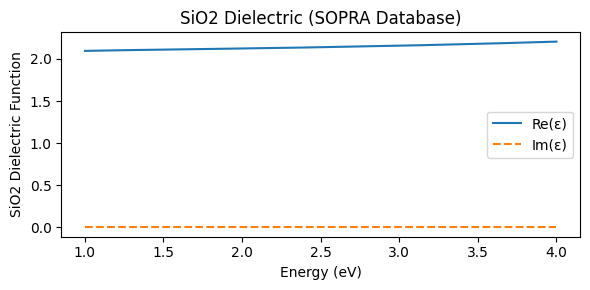

In [4]:
# ---------------------------------------------------------------------------
# SiO2 dielectric from SOPRA database
# ---------------------------------------------------------------------------

def import_sopra_sio2(filepath, energy_grid):
    """
    Parse the SOPRA-format SiO2 optical constants file.
    
    File format: fields delimited by '*' characters.
    Returns complex dielectric function (n + ik)^2 interpolated onto energy_grid.
    """
    wavelength_nm, n_complex = [], []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('*')
            # SOPRA format: *index*wavelength*n*k*...
            wav = float(parts[2])
            n_re = float(parts[3])
            n_im = float(parts[4])
            wavelength_nm.append(wav)
            n_complex.append(n_re + 1j * n_im)
    
    energies = 1239.8 / np.flip(wavelength_nm)
    eps = np.flip(np.array(n_complex))**2
    return np.interp(energy_grid, energies, eps)

sio2_file = DATA_DIR / "Si_SiO2" / "SiO2.txt"
diel_sio2 = import_sopra_sio2(sio2_file, E0)

plt.figure(figsize=(6, 3))
plt.plot(E0, diel_sio2.real, label="Re(ε)")
plt.plot(E0, diel_sio2.imag, label="Im(ε)", linestyle='--')
plt.xlabel("Energy (eV)")
plt.ylabel("SiO2 Dielectric Function")
plt.legend()
plt.title("SiO2 Dielectric (SOPRA Database)")
plt.tight_layout()
plt.show()


## 3. Booker Quartic: *k*_z Solver <a id="3-booker-quartic-kz-solver"></a>

The Booker quartic (Eq. S4 in the Supplementary Information) gives *k*_z as a function of in-plane wavevector for a biaxial medium:

$$\varepsilon_z k_z^4 + b_0 k_z^2 + c_0 = 0$$

where:
- $b_0 = (\varepsilon_x + \varepsilon_z)k_x^2 + (\varepsilon_y + \varepsilon_z)k_y^2 - \varepsilon_z(\varepsilon_x + \varepsilon_y)k_0^2$
- $c_0 = (k_0^2\varepsilon_z - k_x^2 - k_y^2)(k_0^2\varepsilon_x\varepsilon_y - \varepsilon_x k_x^2 - \varepsilon_y k_y^2)$

The two roots correspond to the *a* mode and *b* mode. Care must be taken to select the correct branch of the square root in different regions of reciprocal space (elliptical, ghost, hyperbolic, lenticular).


In [5]:
# ---------------------------------------------------------------------------
# Convenience trig functions
# ---------------------------------------------------------------------------
sin2 = lambda theta: np.sin(theta)**2
cos2 = lambda theta: np.cos(theta)**2


def kz_uniaxial(omega, kx, eps_xy, eps_z):
    """
    k_z for a uniaxial medium (used as a limiting check).
    
    k_z² = ε_xy(k₀² − k_x²/ε_z)
    """
    k0 = omega / C_LIGHT
    return np.emath.sqrt(eps_xy * k0**2 - (eps_xy / eps_z) * kx**2)


def kz_biaxial(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="a"):
    """
    Solve the Booker quartic for k_z in a biaxial medium.
    
    The in-plane wavevector is specified in polar coordinates (k_mag, phi)
    where phi is measured from the crystal a-axis (x-axis).
    
    Parameters
    ----------
    omega : float
        Photon energy (eV).
    k_mag : float
        Magnitude of in-plane wavevector (μm⁻¹).
    phi : float
        Azimuthal angle of propagation (radians), measured from a-axis.
    eps_x, eps_y, eps_z : complex
        Components of the diagonal dielectric tensor.
    mode : str
        'a' for the a-mode, 'b' for the b-mode.
    
    Returns
    -------
    complex
        k_z value for the requested mode.
    
    Notes
    -----
    The sign conventions for the square root are chosen to ensure continuity
    across the different reciprocal-space regions (elliptical, ghost, 
    hyperbolic, lenticular). See Supplementary Information §2.
    """
    # Rotated dielectric tensor components
    eps_xx = eps_x * cos2(phi) + eps_y * sin2(phi)
    eps_yy = eps_x * sin2(phi) + eps_y * cos2(phi)
    eps_xy = (eps_y - eps_x) * np.cos(phi) * np.sin(phi)
    
    k0 = omega / C_LIGHT
    
    # Booker quartic coefficients (Eq. S4-S7)
    b = k_mag**2 * (eps_xx + eps_z) - eps_z * (eps_xx + eps_yy) * k0**2
    c1 = ((eps_z * k0**2 - k_mag**2) * 
          (eps_xx * eps_yy * k0**2 - eps_xx * k_mag**2 - k0**2 * eps_xy**2))
    
    discriminant = b**2 - 4 * eps_z * c1
    sqrt_disc = np.emath.sqrt(discriminant)
    
    # Characteristic wavevectors for region identification
    circle_z = np.sqrt(eps_z.real * k0**2) if np.isreal(eps_z) else np.sqrt(np.abs(eps_z) * k0**2)
    
    psi = np.pi/2 - np.abs(np.abs(phi) - np.pi/2)  # Map to first quadrant
    
    # Ghost mode boundaries
    A = np.emath.sqrt(np.abs(eps_x - eps_z) / eps_z)
    B = np.emath.sqrt(np.abs(eps_y - eps_z) / eps_z)
    C_ghost = np.emath.sqrt(np.abs(eps_x - eps_y)) * k0
    
    gm_lower = C_ghost / (B * np.sin(psi) + A * np.cos(psi))
    gm_upper = -C_ghost / (B * np.sin(psi) - A * np.cos(psi))
    
    hyperbola = np.emath.sqrt(k0**2 / (cos2(phi)/eps_y.real + sin2(phi)/eps_x.real))
    
    # Branch selection: choose correct sign of sqrt to maintain continuity
    if discriminant.imag == 0:
        if hasattr(hyperbola, 'real') and hyperbola.real != 0:
            if k_mag >= gm_upper and k_mag < hyperbola:
                sqrt_b = -1 * sqrt_disc * np.sign(sqrt_disc)
            elif k_mag >= hyperbola:
                sqrt_b = -1 * sqrt_disc * np.sign(sqrt_disc)
        if hasattr(hyperbola, 'real') and hyperbola.real == 0:
            if k_mag < gm_lower and k_mag >= circle_z:
                sqrt_b = sqrt_disc * np.sign(sqrt_disc)
            elif k_mag >= gm_lower and k_mag < gm_upper:
                sqrt_b = -1 * np.sign(sqrt_disc) * sqrt_disc
            else:
                sqrt_b = -1 * sqrt_disc * np.sign(sqrt_disc)
        # Override for specific regions
        if k_mag < circle_z:
            sqrt_b = sqrt_disc * np.sign(sqrt_disc)
        if k_mag >= circle_z and k_mag < gm_lower:
            sqrt_b = sqrt_disc * np.sign(sqrt_disc)
        if k_mag >= gm_lower and k_mag < gm_upper:
            sqrt_b = -1 * np.sign(sqrt_disc) * sqrt_disc
        sqrt_a = -1 * sqrt_b
    else:
        # Complex discriminant (ghost region)
        sqrt_a = sqrt_disc
        sqrt_b = -sqrt_disc
    
    kz_a = np.emath.sqrt((-b + sqrt_a) / (2 * eps_z))
    kz_b = np.emath.sqrt((-b + sqrt_b) / (2 * eps_z))
    
    if mode == 'a':
        return kz_a
    elif mode == 'b':
        return kz_b
    else:
        raise ValueError(f"mode must be 'a' or 'b', got '{mode}'")


## 4. Polarization Vector Calculations <a id="4-polarization-vector-calculations"></a>

For each mode, the polarization (E-field direction) is determined by fixing one component and solving the wave equation (Eqs. S11–S18 in the Supplement). The *a* mode has E_x = 1, and the *b* mode has E_y = 1, with the other components determined by the wave equation.

This produces the polarization maps shown in **Figure S2** and the publication quality figures that are shown in **Section 6**.


In [6]:
def polarization_vector_xy(omega, kx, ky, eps_x, eps_y, eps_z, mode="a"):
    """
    Calculate the normalized polarization vector for a given (kx, ky) point.
    
    Parameters
    ----------
    omega : float
        Photon energy (eV).
    kx, ky : float
        In-plane wavevector components (μm⁻¹).
    eps_x, eps_y, eps_z : float
        Real parts of the diagonal dielectric tensor.
    mode : str
        'a' or 'b' mode.
    
    Returns
    -------
    Ex, Ey, Ez : float
        Normalized polarization vector components |E_i|/|E|.
    
    Notes
    -----
    Implements Eqs. S11–S18 of the Supplementary Information.
    For the a-mode, E_x is fixed to 1 and E_y, E_z are solved.
    For the b-mode, E_y is fixed to 1 and E_x, E_z are solved.
    """
    phi = np.arctan2(ky, kx)
    k_mag = np.sqrt(kx**2 + ky**2)
    k0 = omega / C_LIGHT
    
    kz_a = kz_biaxial(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="a")
    kz_b = kz_biaxial(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="b")
    
    def solve_polarization(kz, mode_type):
        # Diagonal elements of the wave equation matrix (Eqs. S9–S11)
        del_x = eps_x * k0**2 - ky**2 - kz**2
        del_y = eps_y * k0**2 - kx**2 - kz**2
        del_z = eps_z * k0**2 - kx**2 - ky**2
        
        if mode_type == "a":
            Ex0 = 1.0
            Ez0 = kx * kz * (del_y - ky**2) / (ky**2 * kz**2 - del_y * del_z)
            Ey0 = -ky * (kz * Ez0 + kx) / del_y
        else:  # b mode
            Ey0 = 1.0
            Ez0 = ky * kz * (del_x - kx**2) / (kx**2 * kz**2 - del_x * del_z)
            Ex0 = (kx * kz * Ez0 - kx * ky) / del_x
        
        # Normalize
        E_mag = np.sqrt(np.abs(Ex0)**2 + np.abs(Ey0)**2 + np.abs(Ez0)**2)
        return np.abs(Ex0)/E_mag, np.abs(Ey0)/E_mag, np.abs(Ez0)/E_mag
    
    kz = kz_a if mode == "a" else kz_b
    return solve_polarization(kz, mode)


def compute_polarization_grid(omega, kx_arr, ky_arr, eps_x, eps_y, eps_z, mode="a"):
    """
    Compute polarization vectors on a 2D (kx, ky) grid.
    
    Returns
    -------
    Ex, Ey, Ez : 2D arrays
        Normalized polarization components on the (ky, kx) grid.
    """
    nx, ny = len(kx_arr), len(ky_arr)
    Ex = np.zeros((ny, nx))
    Ey = np.zeros((ny, nx))
    Ez = np.zeros((ny, nx))
    
    for i, kx in enumerate(kx_arr):
        for j, ky in enumerate(ky_arr):
            ex, ey, ez = polarization_vector_xy(omega, kx, ky, eps_x, eps_y, eps_z, mode=mode)
            Ex[j, i] = ex
            Ey[j, i] = ey
            Ez[j, i] = ez
    
    return Ex, Ey, Ez


## 5. Isofrequency Surface Calculations <a id="5-isofrequency-surface-calculations"></a>

The isofrequency contour (IFC) shows k_z(k_x, k_y) at a fixed energy. This reveals the different mode regions:
- **Propagating** (Re k_z > 0, Im k_z ≈ 0): inside the ε_z circle or hyperbolic region
- **Evanescent** (Re k_z ≈ 0, Im k_z > 0): outside the hyperbolic region for the a-mode
- **Ghost** (both Re and Im k_z nonzero): where the discriminant is negative

These are shown in **Figures 2B-C, E-F** of the main text.


In [7]:
def compute_isofrequency(omega, kx_arr, eps_x, eps_y, eps_z, mode="a"):
    """
    Compute the isofrequency surface k_z(kx, ky) for a biaxial medium.
    
    Parameters
    ----------
    omega : float
        Photon energy (eV).
    kx_arr : array_like
        1D array of k values used for both kx and ky axes (μm⁻¹).
    eps_x, eps_y, eps_z : complex
        Dielectric tensor components at this energy.
    mode : str
        'a' or 'b' mode.
    
    Returns
    -------
    kz_grid : 2D complex array
        k_z values on the (ky, kx) grid.
    """
    ky_arr = kx_arr
    n = len(kx_arr)
    kz_re = np.zeros((n, n))
    kz_im = np.zeros((n, n))
    
    for i, kx in enumerate(kx_arr):
        for j, ky in enumerate(ky_arr):
            phi = np.arctan2(ky, kx)
            k_mag = np.sqrt(kx**2 + ky**2)
            kz = kz_biaxial(omega, k_mag, phi, eps_x.real, eps_y.real, 
                           eps_z.real, mode=mode)
            if kz.real < 0:
                kz = -kz
            kz_re[j, i] = kz.real
            kz_im[j, i] = kz.imag
    
    return kz_re + 1j * kz_im


def compute_reference_curves(omega, kx_arr, eps_x, eps_y, eps_z):
    """
    Compute reference curves for IFC plots: light line, ε_z circle,
    hyperbola, and ghost mode boundaries.
    
    Returns
    -------
    dict with keys: 'light_line', 'circle_z', 'hyperbola', 'ghost_A', 
                    'ghost_B', 'ghost_C', 'si_light_line'
    """
    k0 = omega / C_LIGHT
    
    light_line = np.sqrt(k0**2 - kx_arr**2)
    circle_z = np.sqrt(eps_z.real * k0**2 - kx_arr**2)
    si_light_line = np.sqrt(2.11 * k0**2 - kx_arr**2)  # n_Si ≈ 1.45 at visible
    hyperbola = np.emath.sqrt(eps_y.real * (k0**2 - kx_arr**2 / eps_x.real))
    
    A = np.sqrt(np.abs(eps_x.real - eps_z.real) / eps_z.real)
    B = np.sqrt(np.abs(eps_y.real - eps_z.real) / eps_z.real)
    C_val = np.sqrt(np.abs(eps_x.real - eps_y.real)) * k0
    
    return {
        'light_line': light_line,
        'circle_z': circle_z,
        'si_light_line': si_light_line,
        'hyperbola': hyperbola,
        'A': A, 'B': B, 'C': C_val,
        'kx': kx_arr
    }


## 6. Generate Publication Figures <a id="6-generate-publication-figures"></a>

### 6.1 Polarization Maps (Figure S2)

Polarization of the *a* and *b* modes as a function of wavevector at 770 nm (1.61 eV). 
The colormap shows |E_z| and the vector field shows in-plane polarization (|E_x|, |E_y|).


In [8]:
# ---------------------------------------------------------------------------
# Compute polarization maps at 770 nm
# ---------------------------------------------------------------------------
ind = get_nearest_index(E0, ENERGY_DEFAULT)
epsx = melchioni_x[ind].real
epsy = melchioni_y[ind].real
epsz = z_dft[ind].real

# Fine grid for colormap
k_fine = np.linspace(-30, 30, 200)
# Coarse grid for quiver arrows  
k_quiver = np.concatenate((np.linspace(-30, 0, 10), np.linspace(0, 30, 10)))

# Reference curves
A_ghost = np.sqrt(np.abs(epsx - epsz) / epsz)
B_ghost = np.sqrt(np.abs(epsy - epsz) / epsz)
C_ghost = np.sqrt(np.abs(epsx - epsy)) * (ENERGY_DEFAULT / C_LIGHT)
hyperbola = np.emath.sqrt(epsy * ((ENERGY_DEFAULT/C_LIGHT)**2 - k_fine**2 / epsx))

print(f"Computing polarization maps at {ENERGY_DEFAULT:.3f} eV...")
print(f"  ε_x = {epsx:.3f}, ε_y = {epsy:.3f}, ε_z = {epsz:.3f}")


Computing polarization maps at 1.610 eV...
  ε_x = -7.443, ε_y = 5.973, ε_z = 3.767


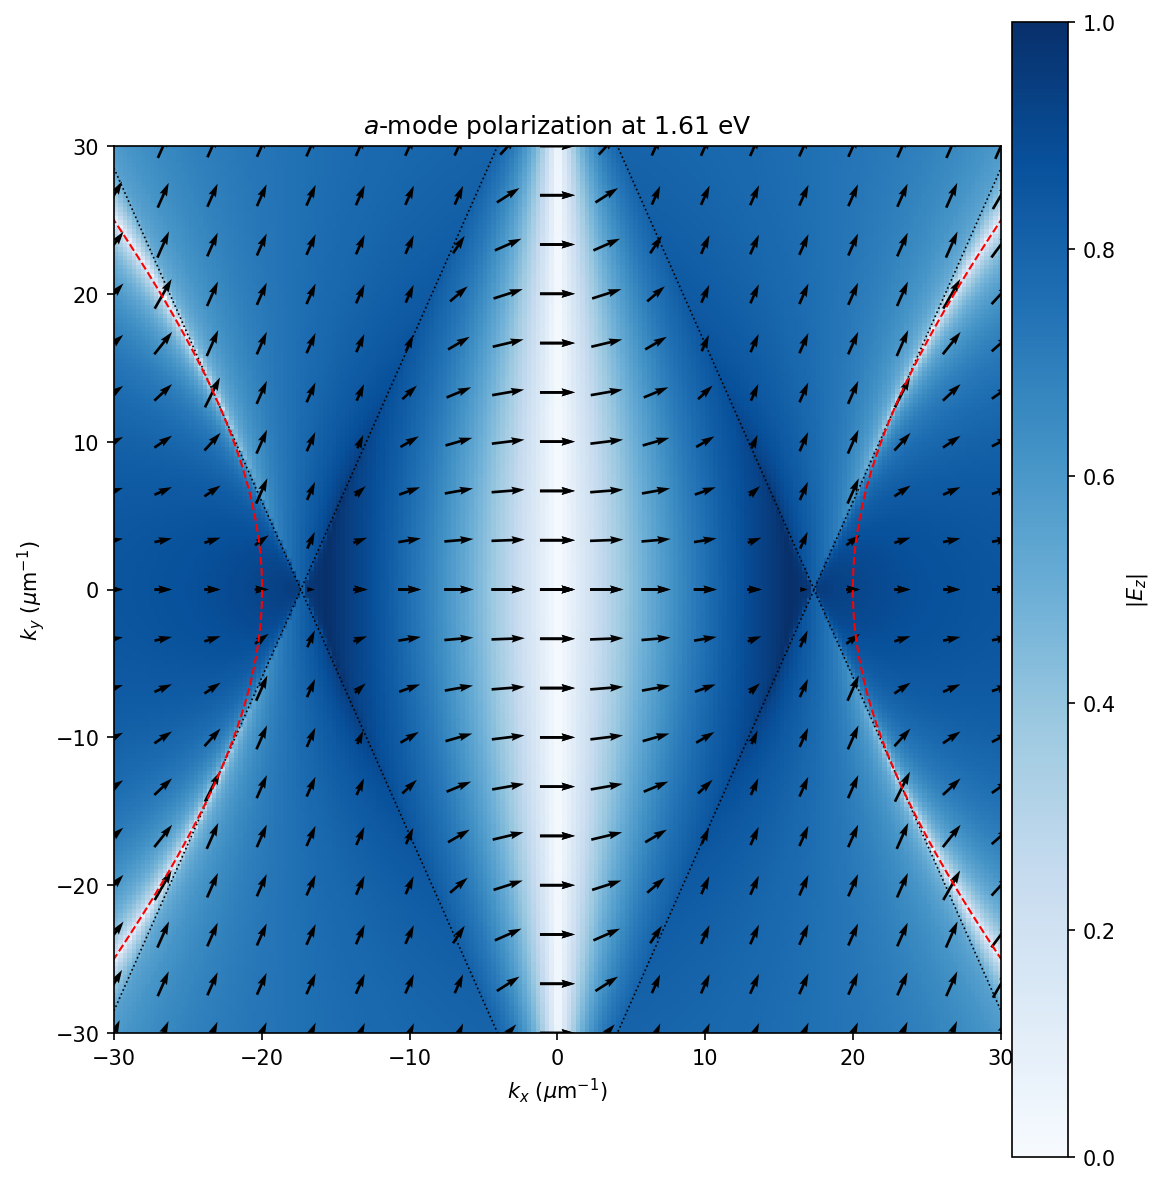

In [9]:
# ---------------------------------------------------------------------------
# a-mode polarization (Figure S2A)
# ---------------------------------------------------------------------------
Ex_a, Ey_a, Ez_a = compute_polarization_grid(
    ENERGY_DEFAULT, k_fine, k_fine, epsx, epsy, epsz, mode="a")
Ex_a_q, Ey_a_q, Ez_a_q = compute_polarization_grid(
    ENERGY_DEFAULT, k_quiver, k_quiver, epsx, epsy, epsz, mode="a")

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
im = ax.imshow(Ez_a, cmap=cm.Blues, aspect='equal',
               extent=[k_fine[0], k_fine[-1], k_fine[0], k_fine[-1]],
               vmin=0, vmax=1, origin='lower')

# Ghost mode boundaries
ax.plot(k_fine, (C_ghost/B_ghost + k_fine*A_ghost/B_ghost), 'k:', lw=0.8, label='Ghost mode')
ax.plot(k_fine, (-C_ghost/B_ghost - k_fine*A_ghost/B_ghost), 'k:', lw=0.8)
ax.plot(k_fine, (-C_ghost/B_ghost + k_fine*A_ghost/B_ghost), 'k:', lw=0.8)
ax.plot(k_fine, (C_ghost/B_ghost - k_fine*A_ghost/B_ghost), 'k:', lw=0.8)

# Hyperbola
ax.plot(hyperbola, k_fine, 'r--', lw=1, label='Hyperbola')
ax.plot(-1*hyperbola, k_fine, 'r--', lw=1)

# Quiver plot for in-plane polarization
ax.quiver(k_quiver, k_quiver, Ex_a_q, Ey_a_q, units='xy', pivot='mid')

ax.set_xlim([-30, 30])
ax.set_ylim([-30, 30])
ax.set_xlabel(r"$k_x$ ($\mu$m$^{-1}$)")
ax.set_ylabel(r"$k_y$ ($\mu$m$^{-1}$)")
ax.set_title(f"$a$-mode polarization at {ENERGY_DEFAULT:.2f} eV")
plt.colorbar(im, ax=ax, pad=0.01, label=r'$|E_z|$')
plt.tight_layout()
plt.savefig("a_pol.eps", dpi=500)
plt.show()


C:\Users\sbking\AppData\Local\Temp\ipykernel_41416\1344475641.py:9: RuntimeWarning: invalid value encountered in sqrt
  circle_z_curve = np.sqrt(epsz * (ENERGY_DEFAULT/C_LIGHT)**2 - k_fine**2)


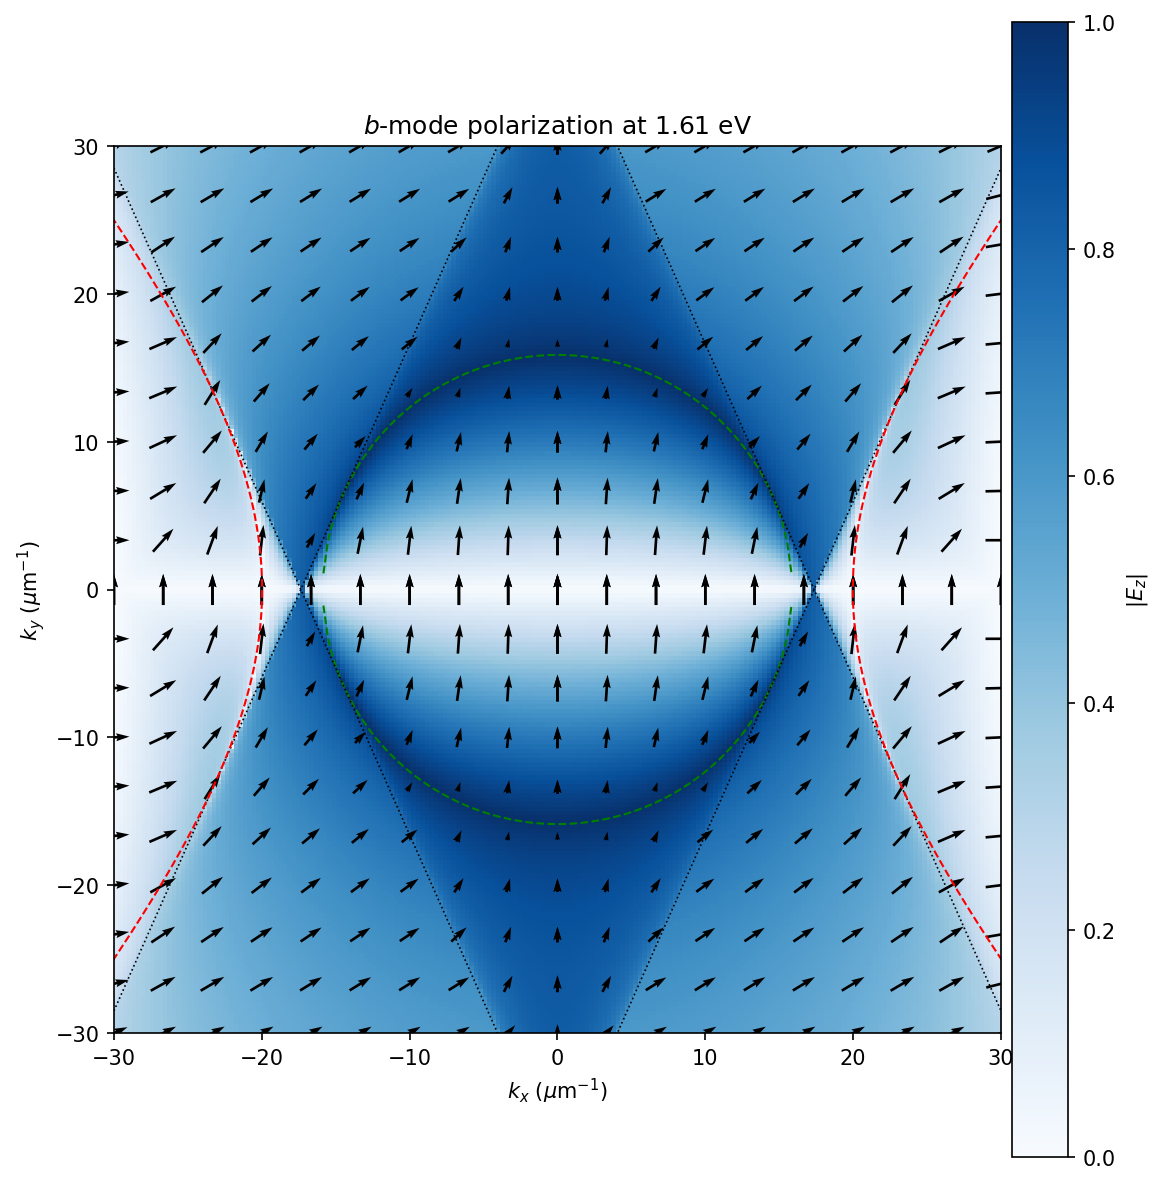

In [10]:
# ---------------------------------------------------------------------------
# b-mode polarization (Figure S2B)
# ---------------------------------------------------------------------------
Ex_b, Ey_b, Ez_b = compute_polarization_grid(
    ENERGY_DEFAULT, k_fine, k_fine, epsx, epsy, epsz, mode="b")
Ex_b_q, Ey_b_q, Ez_b_q = compute_polarization_grid(
    ENERGY_DEFAULT, k_quiver, k_quiver, epsx, epsy, epsz, mode="b")

circle_z_curve = np.sqrt(epsz * (ENERGY_DEFAULT/C_LIGHT)**2 - k_fine**2)

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
im = ax.imshow(Ez_b, cmap=cm.Blues, aspect='equal',
               extent=[k_fine[0], k_fine[-1], k_fine[0], k_fine[-1]],
               vmin=0, vmax=1, origin='lower')

# ε_z circle
ax.plot(k_fine, circle_z_curve, 'g--', lw=1, label=r'$varepsilon_z$ circle')
ax.plot(k_fine, -1*circle_z_curve, 'g--', lw=1)

# Ghost mode boundaries  
ax.plot(k_fine, (C_ghost/B_ghost + k_fine*A_ghost/B_ghost), 'k:', lw=0.8, label='Ghost mode')
ax.plot(k_fine, (-C_ghost/B_ghost - k_fine*A_ghost/B_ghost), 'k:', lw=0.8)
ax.plot(k_fine, (-C_ghost/B_ghost + k_fine*A_ghost/B_ghost), 'k:', lw=0.8)
ax.plot(k_fine, (C_ghost/B_ghost - k_fine*A_ghost/B_ghost), 'k:', lw=0.8)

# Hyperbola
ax.plot(hyperbola, k_fine, 'r--', lw=1, label='Hyperbola')
ax.plot(-1*hyperbola, k_fine, 'r--', lw=1)

# Quiver plot
ax.quiver(k_quiver, k_quiver, Ex_b_q, Ey_b_q, units='xy', pivot='mid')

ax.set_xlim([-30, 30])
ax.set_ylim([-30, 30])
ax.set_xlabel(r"$k_x$ ($\mu$m$^{-1}$)")
ax.set_ylabel(r"$k_y$ ($\mu$m$^{-1}$)")
ax.set_title(f"$b$-mode polarization at {ENERGY_DEFAULT:.2f} eV")
plt.colorbar(im, ax=ax, pad=0.01, label=r'$|E_z|$')
plt.tight_layout()
plt.savefig("b_pol.eps", dpi=500)
plt.show()


### 6.2 Isofrequency Contours (Main Text Figures 2B–F)

Real and imaginary parts of k_z for the *a* and *b* modes at 770 nm.
These plots include overlays of the light line, SiO₂ light line, ε_z circle, 
hyperbolic curve, and ghost mode boundaries.


In [11]:
# ---------------------------------------------------------------------------
# Helper: plot a single isofrequency panel
# ---------------------------------------------------------------------------

def plot_ifc_panel(kz_grid, kx_arr, refs, mode_label, component="real",
                   vmin=None, vmax=None, exp_point=None, save_name=None):
    """
    Plot one panel of an isofrequency surface.
    
    Parameters
    ----------
    kz_grid : 2D complex array
        k_z values on the grid.
    kx_arr : array_like
        k values for the axis.
    refs : dict
        Reference curves from compute_reference_curves().
    mode_label : str
        Label for the mode ('a' or 'b').
    component : str
        'real' or 'imag'.
    exp_point : tuple or None
        (kx, error) for experimental data point overlay.
    save_name : str or None
        Filename to save the figure.
    """
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
    kx_ref = refs['kx']
    A, B, C = refs['A'], refs['B'], refs['C']
    
    if component == "real":
        data = kz_grid.real
        cmap = cm.Blues
        title = f"${mode_label}$ mode: Re($k_z$) at {ENERGY_DEFAULT:.2f} eV"
        clabel = r'Re $k_z$ ($\mu$m$^{-1}$)'
    else:
        data = np.abs(kz_grid.imag)
        cmap = cm.Reds
        title = f"${mode_label}$ mode: Im($k_z$) at {ENERGY_DEFAULT:.2f} eV"
        clabel = r'Im $k_z$ ($\mu$m$^{-1}$)'
        
    im = ax.imshow(data, cmap=cmap, aspect='equal',
                   extent=[kx_arr[0], kx_arr[-1], kx_arr[0], kx_arr[-1]],
                   vmin=vmin, vmax=vmax, origin='lower')
    
    # Reference curves
    ax.plot(kx_ref, refs['light_line'], 'k--', lw=0.8, label='Light line')
    ax.plot(kx_ref, -refs['light_line'], 'k--', lw=0.8)
    ax.plot(kx_ref, refs['si_light_line'], 'b--', lw=0.8, label='Si light line')
    ax.plot(kx_ref, -refs['si_light_line'], 'b--', lw=0.8)
    ax.plot(refs['hyperbola'], kx_ref, 'r--', lw=1, label='Hyperbola')
    ax.plot(-refs['hyperbola'], kx_ref, 'r--', lw=1)
    ax.plot(kx_ref, refs['circle_z'], 'g--', lw=0.8, label=r'$\varepsilon_z$ circle')
    ax.plot(kx_ref, -refs['circle_z'], 'g--', lw=0.8)
    
    # Ghost mode lines
    ax.plot(kx_ref, (C/B + kx_ref*A/B), 'k:', lw=0.6)
    ax.plot(kx_ref, (-C/B - kx_ref*A/B), 'k:', lw=0.6)
    ax.plot(kx_ref, (-C/B + kx_ref*A/B), 'k:', lw=0.6)
    ax.plot(kx_ref, (C/B - kx_ref*A/B), 'k:', lw=0.6)
    
    # Experimental data point
    if exp_point is not None:
        ax.errorbar(exp_point[0], 0, xerr=exp_point[1], fmt='o', 
                    color='blue', ecolor='blue', capsize=3)
    
    ax.set_xlim([-30, 30])
    ax.set_ylim([-30, 30])
    ax.set_xlabel(r"$k_x$ ($\mu$m$^{-1}$)")
    ax.set_ylabel(r"$k_y$ ($\mu$m$^{-1}$)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, pad=0.01, label=clabel)
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    
    if save_name:
        plt.savefig(save_name, dpi=500)
    plt.show()


In [12]:
# ---------------------------------------------------------------------------
# Compute IFCs for both modes
# ---------------------------------------------------------------------------
kx_ifc = np.linspace(-30, 30, 450)
kx_ref = np.linspace(-30, 30, 3500)  # finer grid for smooth reference curves

ind = get_nearest_index(E0, ENERGY_DEFAULT)

print("Computing a-mode isofrequency surface...")
ifs_a = compute_isofrequency(ENERGY_DEFAULT, kx_ifc, 
                              melchioni_x[ind], melchioni_y[ind], z_dft[ind], mode="a")

print("Computing b-mode isofrequency surface...")
ifs_b = compute_isofrequency(ENERGY_DEFAULT, kx_ifc, 
                              melchioni_x[ind], melchioni_y[ind], z_dft[ind], mode="b")

refs = compute_reference_curves(ENERGY_DEFAULT, kx_ref, 
                                melchioni_x[ind], melchioni_y[ind], z_dft[ind])

# Experimental data point at 770 nm: kx = 8.81 ± 0.22 μm⁻¹
exp_data = (8.808, 0.215)

print("Done. Generating figures...")


Computing a-mode isofrequency surface...
Computing b-mode isofrequency surface...
Done. Generating figures...


C:\Users\sbking\AppData\Local\Temp\ipykernel_41416\605640697.py:52: RuntimeWarning: invalid value encountered in sqrt
  light_line = np.sqrt(k0**2 - kx_arr**2)
C:\Users\sbking\AppData\Local\Temp\ipykernel_41416\605640697.py:53: RuntimeWarning: invalid value encountered in sqrt
  circle_z = np.sqrt(eps_z.real * k0**2 - kx_arr**2)
C:\Users\sbking\AppData\Local\Temp\ipykernel_41416\605640697.py:54: RuntimeWarning: invalid value encountered in sqrt
  si_light_line = np.sqrt(2.11 * k0**2 - kx_arr**2)  # n_Si ≈ 1.45 at visible


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


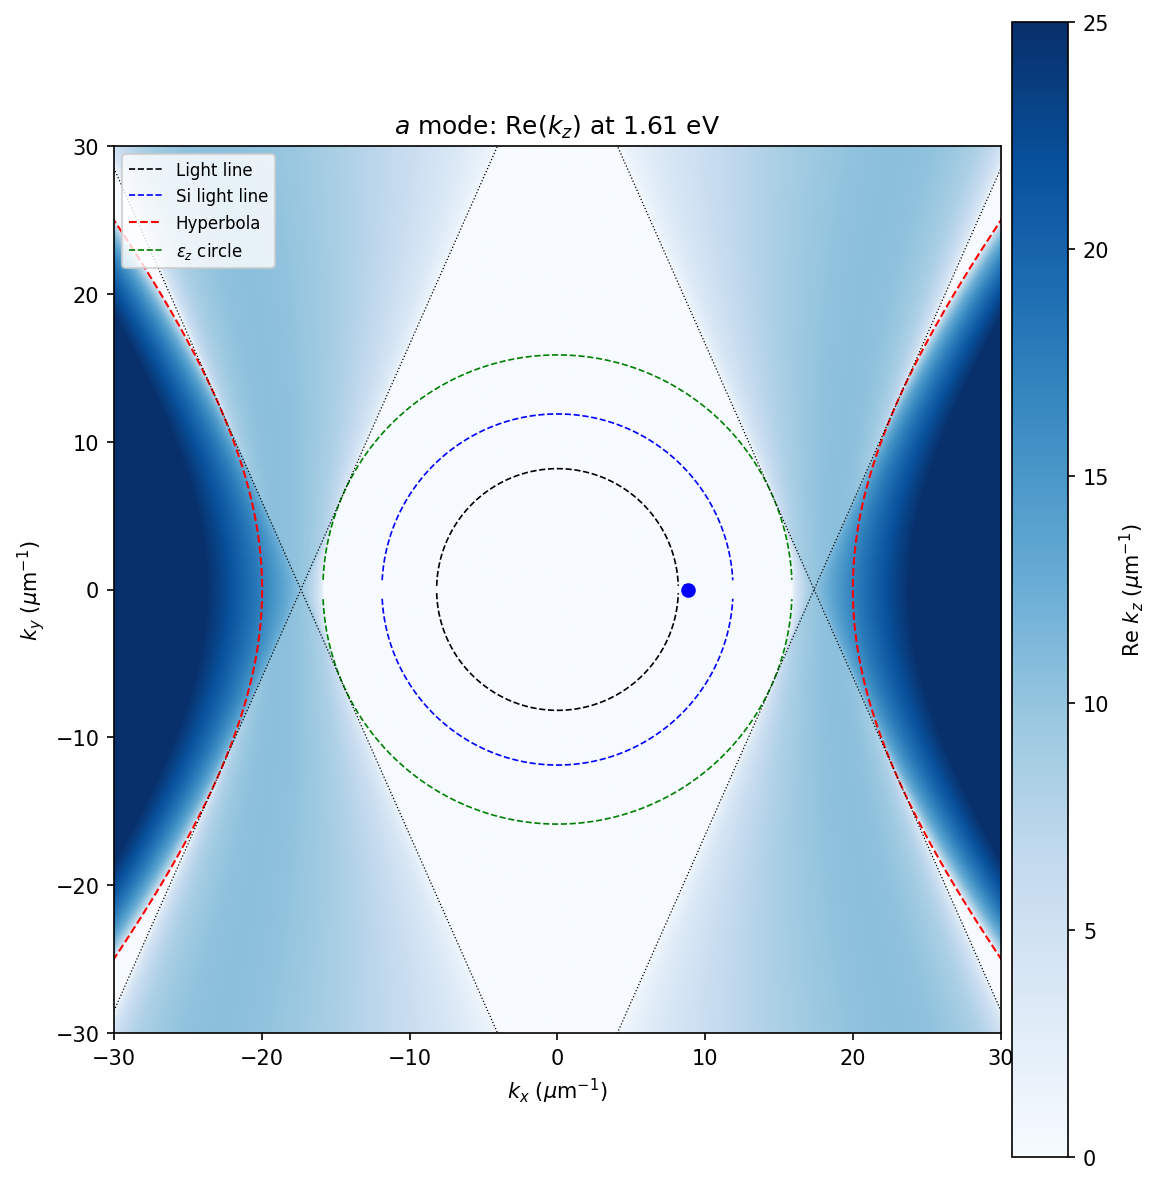

In [13]:
# a-mode: Re(kz) — Main text Fig 2B
plot_ifc_panel(ifs_a, kx_ifc, refs, "a", component="real", 
               vmax=25, exp_point=exp_data, save_name="amode_real.eps")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


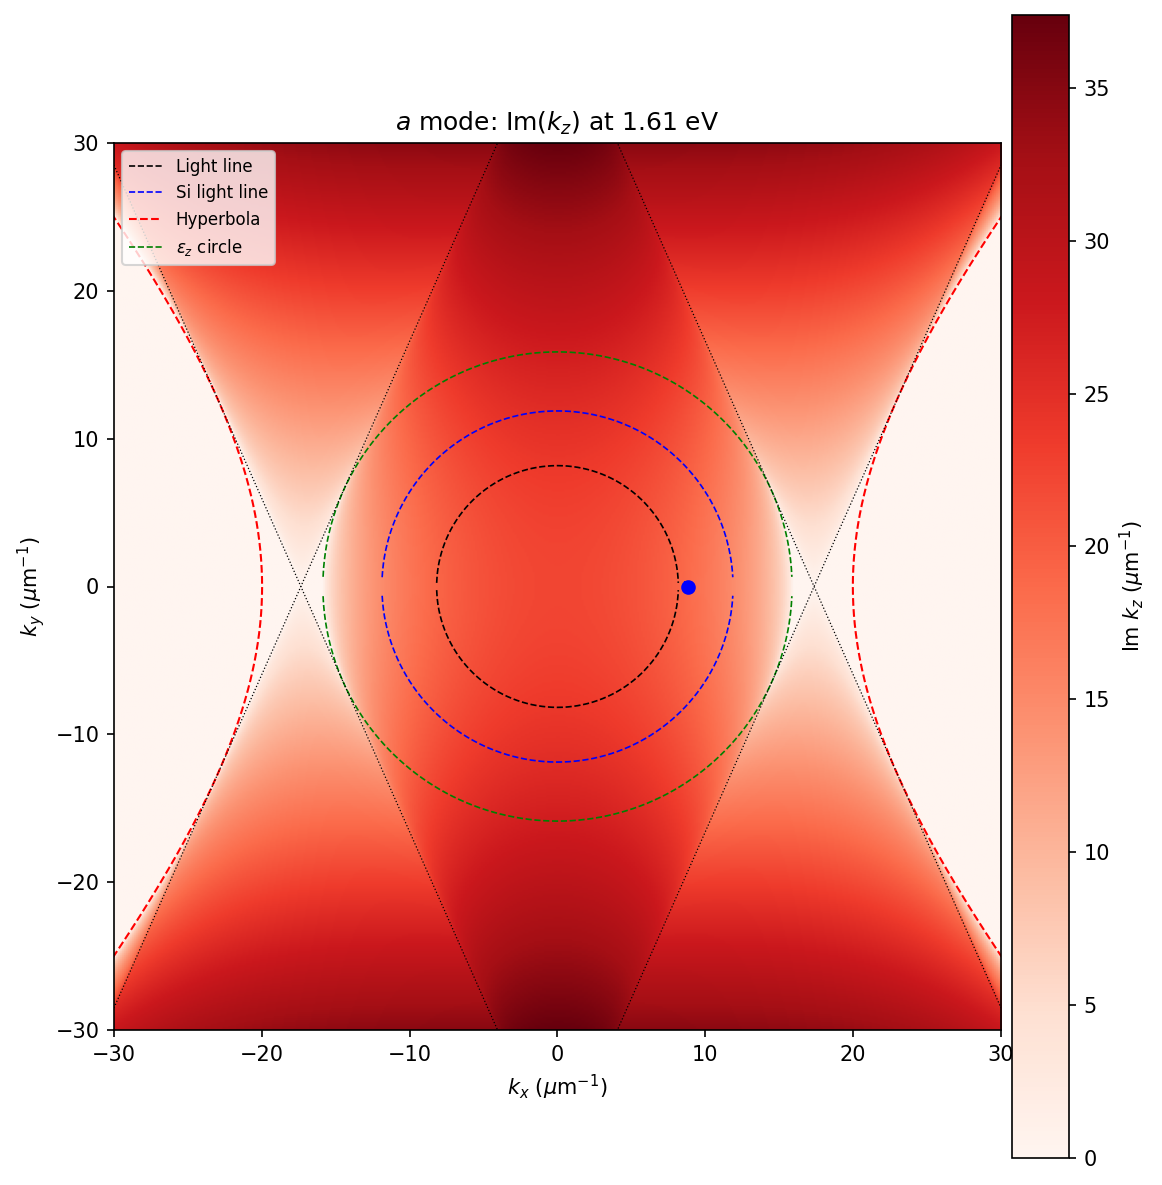

In [14]:
# a-mode: Im(kz) — Main text Fig 2C
plot_ifc_panel(ifs_a, kx_ifc, refs, "a", component="imag",
               vmax=np.max(ifs_a.imag), exp_point=exp_data, save_name="amode_imag.eps")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


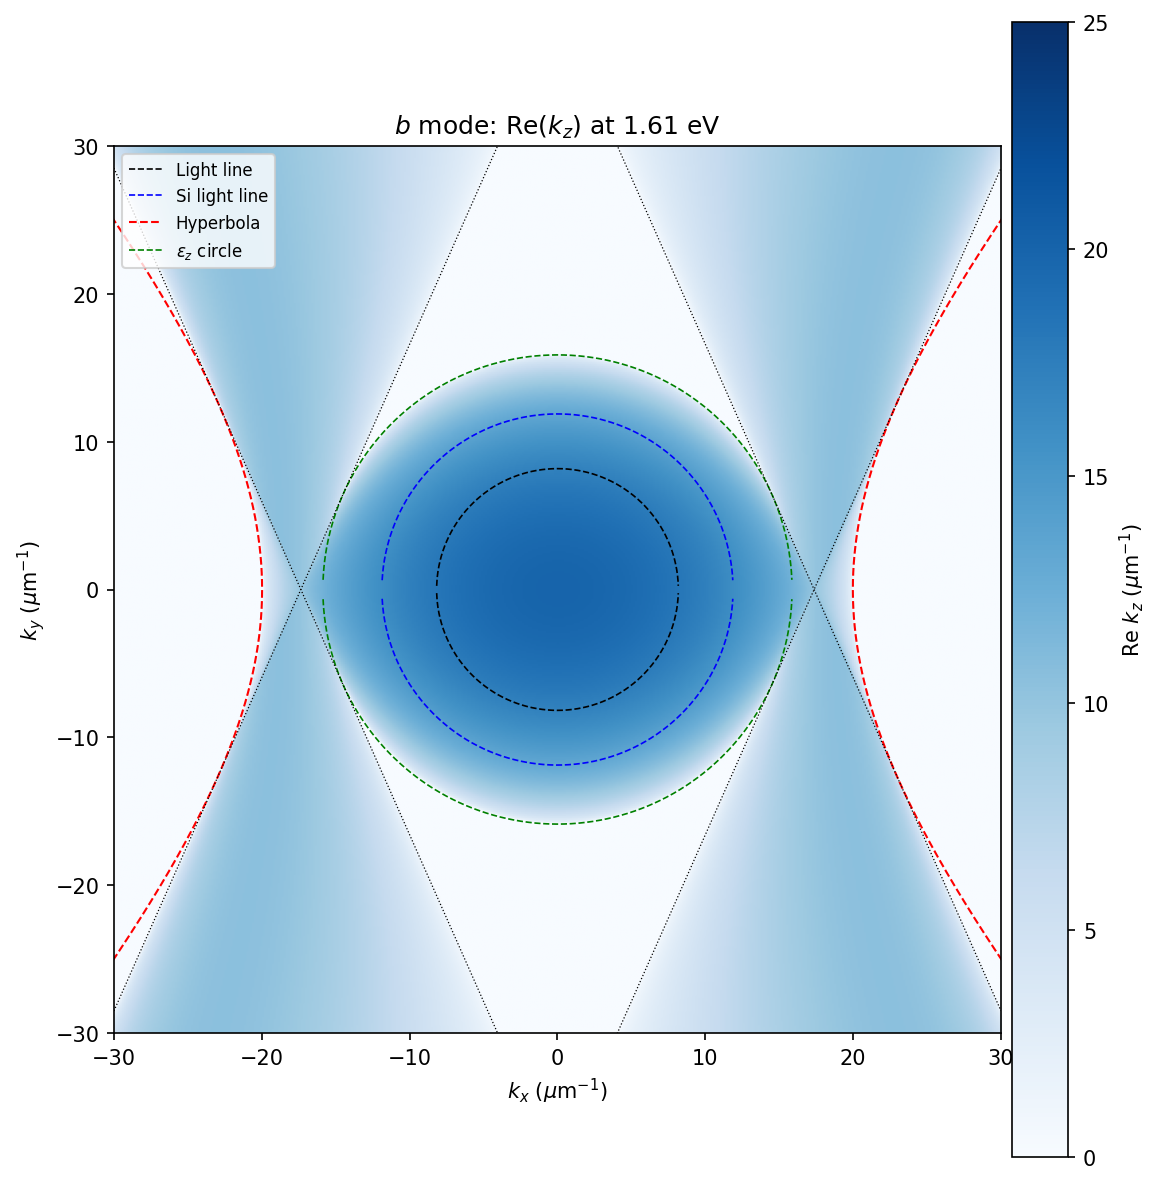

In [15]:
# b-mode: Re(kz) — Main text Fig 2E
plot_ifc_panel(ifs_b, kx_ifc, refs, "b", component="real", 
               vmax=25, save_name="bmode_real.eps")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


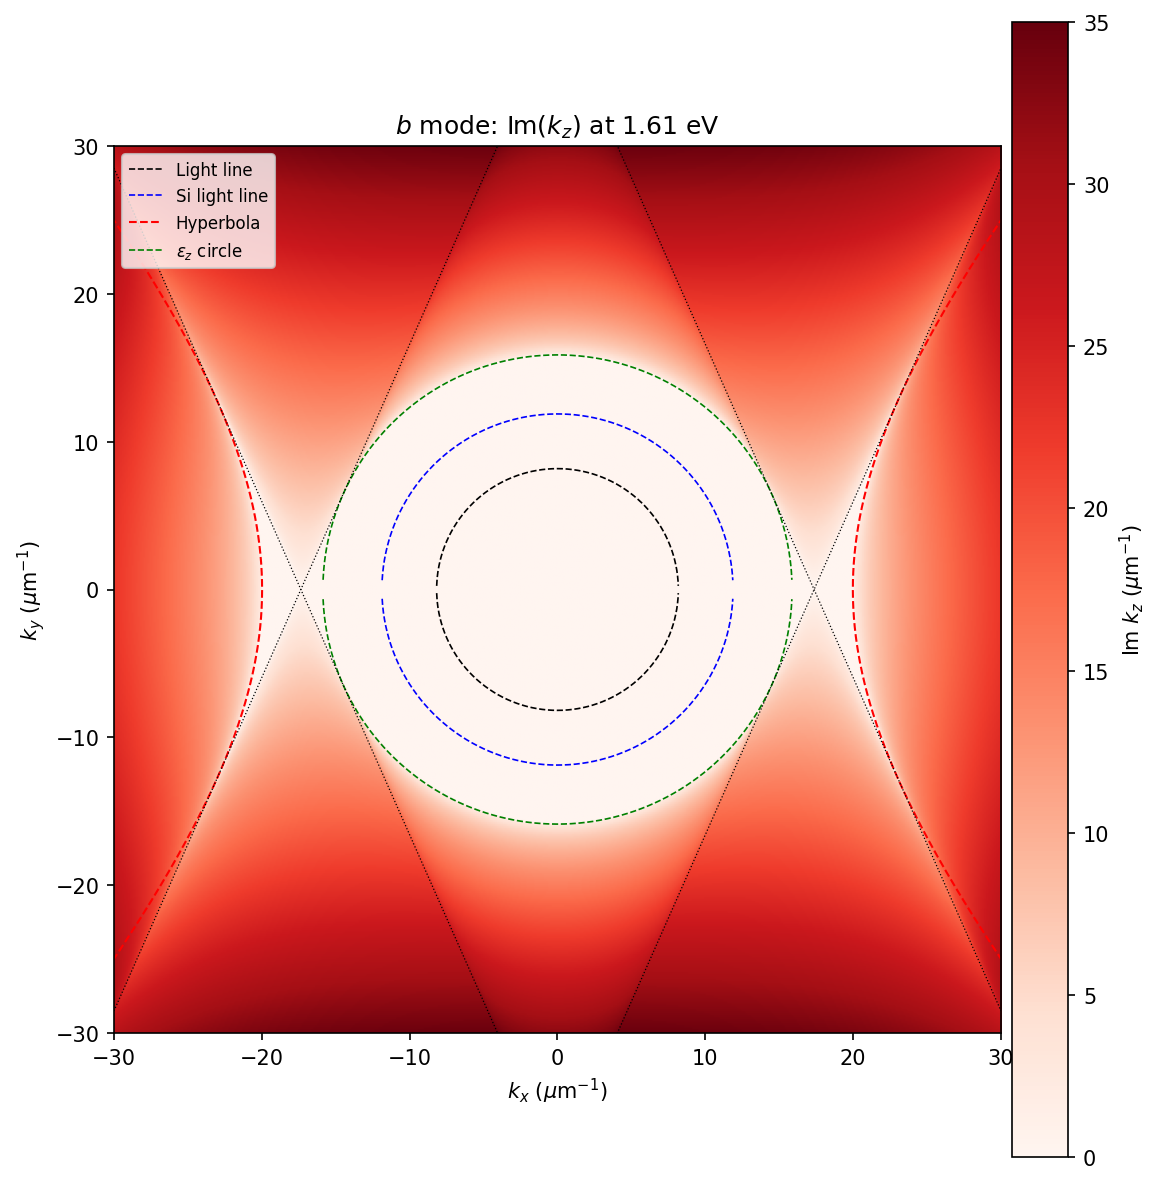

In [16]:
# b-mode: Im(kz) — Main text Fig 2F
plot_ifc_panel(ifs_b, kx_ifc, refs, "b", component="imag",
               vmax=35, save_name="bmode_imag.eps")


### 6.3 Line cuts along principal axes (verification)

As a check, we plot k_z along the principal axes (φ = 0 and φ = π/2) and compare with the uniaxial limit. Along principal axes, the Booker quartic decouples into pure TM and TE modes (see Supplementary Information §2).


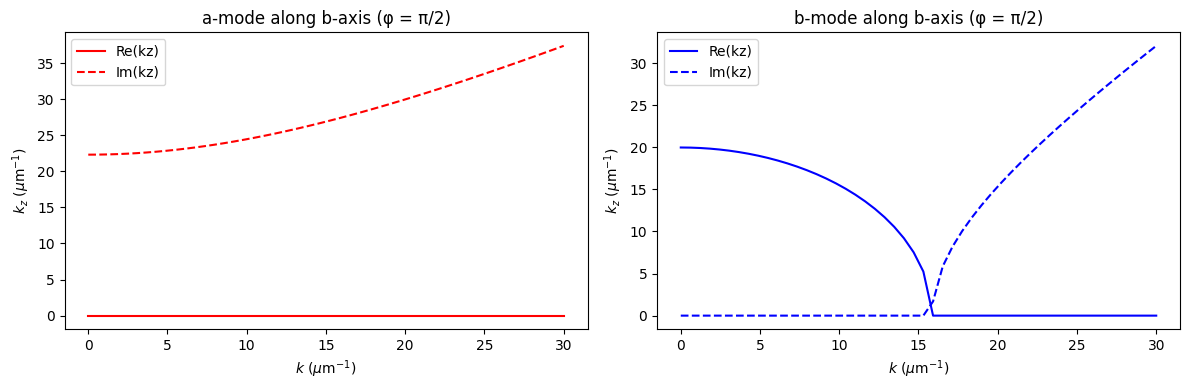

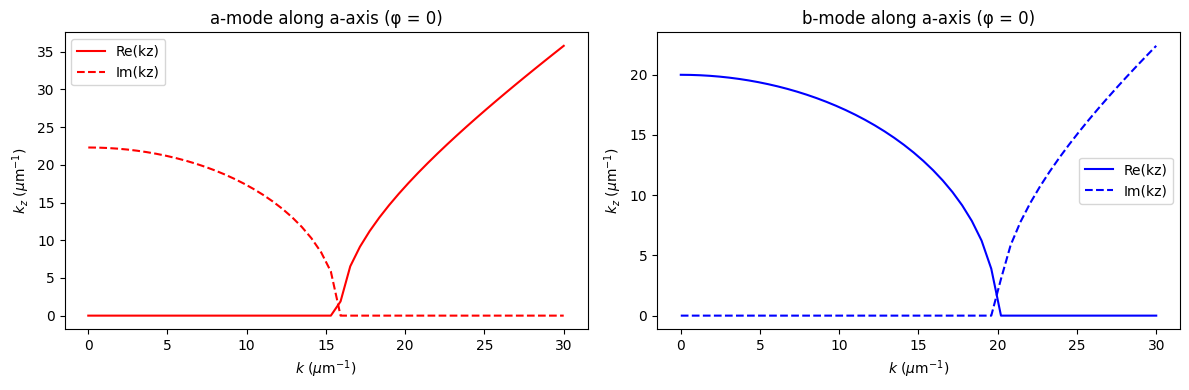

In [17]:
# ---------------------------------------------------------------------------
# k_z line cuts along principal axes for verification
# ---------------------------------------------------------------------------
kx_line = np.linspace(0.01, 30, 50)
ind = get_nearest_index(E0, ENERGY_DEFAULT)

epsx_r = melchioni_x[ind].real
epsy_r = melchioni_y[ind].real
epsz_r = z_dft[ind].real

for phi_val, phi_label in [(np.pi/2, "b-axis (φ = π/2)"), (0.0, "a-axis (φ = 0)")]:
    kz_a_line = np.array([kz_biaxial(ENERGY_DEFAULT, k, phi_val, epsx_r, epsy_r, epsz_r, mode="a") 
                          for k in kx_line])
    kz_b_line = np.array([kz_biaxial(ENERGY_DEFAULT, k, phi_val, epsx_r, epsy_r, epsz_r, mode="b") 
                          for k in kx_line])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(kx_line, kz_a_line.real, 'r-', label='Re(kz)')
    axes[0].plot(kx_line, kz_a_line.imag, 'r--', label='Im(kz)')
    axes[0].set_title(f"a-mode along {phi_label}")
    axes[0].set_xlabel(r"$k$ ($\mu$m$^{-1}$)")
    axes[0].set_ylabel(r"$k_z$ ($\mu$m$^{-1}$)")
    axes[0].legend()
    
    axes[1].plot(kx_line, kz_b_line.real, 'b-', label='Re(kz)')
    axes[1].plot(kx_line, kz_b_line.imag, 'b--', label='Im(kz)')
    axes[1].set_title(f"b-mode along {phi_label}")
    axes[1].set_xlabel(r"$k$ ($\mu$m$^{-1}$)")
    axes[1].set_ylabel(r"$k_z$ ($\mu$m$^{-1}$)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
